Data Collection

In [31]:
import yfinance as yf

ticker='MSFT'
data=yf.download(ticker,start='2015-01-01',end='2026-03-01')
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker           MSFT       MSFT       MSFT       MSFT      MSFT
Date                                                            
2015-01-02  39.767673  40.328979  39.580574  39.682628  27913900
2015-01-05  39.401989  39.742173  39.333950  39.436005  39673900
2015-01-06  38.823666  39.759174  38.730114  39.444504  36447900
2015-01-07  39.316944  39.512550  38.687603  39.104328  29114100
2015-01-08  40.473560  40.609634  39.733658  39.759171  29645200


In [32]:
data.shape

(2805, 5)

Dataset Cleaning

In [33]:
data.columns=[col[0] for col in data.columns] #level 0 columns selected
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,39.767673,40.328979,39.580574,39.682628,27913900
2015-01-05,39.401989,39.742173,39.333950,39.436005,39673900
2015-01-06,38.823666,39.759174,38.730114,39.444504,36447900
2015-01-07,39.316944,39.512550,38.687603,39.104328,29114100
2015-01-08,40.473560,40.609634,39.733658,39.759171,29645200


In [34]:
print(data.columns)     # date is not in the columns
print(type(data.columns))

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
<class 'pandas.Index'>


In [35]:
import pandas as pd
data.index=pd.to_datetime(data.index) # datetime object
print(type(data.index))

<class 'pandas.DatetimeIndex'>


In [36]:
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,39.767673,40.328979,39.580574,39.682628,27913900
2015-01-05,39.401989,39.742173,39.333950,39.436005,39673900
2015-01-06,38.823666,39.759174,38.730114,39.444504,36447900
2015-01-07,39.316944,39.512550,38.687603,39.104328,29114100
2015-01-08,40.473560,40.609634,39.733658,39.759171,29645200


In [41]:
print(data.index.name)
print(data.index.dtype)
print(data.columns)

Date
datetime64[s]
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [42]:
data.isna().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [43]:
data.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

EDA

In [55]:
import plotly.graph_objects as go

fig=go.Figure()
fig.add_trace(go.Scatter(x=data.index,y=data['Open'],mode='lines',name='Open Price'))   # Open Price
fig.add_trace(go.Scatter(x=data.index,y=data['Close'],mode='lines',name='Close Price')) # Close Price

fig.update_layout(title='Microsoft Open vs Closing Stock Price',xaxis_title='Date',yaxis_title='Price($)',
                  xaxis=dict(rangeslider=dict(visible=True)),template='plotly_dark')
fig.show()


In [57]:
data.describe()

,Close,High,Low,Open,Volume
count,2805.000000,2805.000000,2805.000000,2805.000000,2.805000e+03
mean,208.874631,210.784670,206.791019,208.849066,2.841112e+07
std,144.511903,145.726534,143.222832,144.556130,1.328486e+07
min,34.358746,34.894482,34.214161,34.520328,5.855900e+06
25%,70.751900,70.870567,70.532738,70.687961,2.012900e+07
50%,194.987427,198.705302,192.957034,195.549412,2.520130e+07
75%,318.266327,322.060239,314.829516,319.085870,3.279080e+07
max,539.825256,552.242002,538.530652,552.023241,1.691640e+08


In [58]:
# Daily Returns 
data['Daily Returns']=data['Close'].pct_change() # % change between current value & Previous value
data.head()

,Close,High,Low,Open,Volume,Daily Returns
Date,,,,,,
2015-01-02,39.767673,40.328979,39.580574,39.682628,27913900,NaN
2015-01-05,39.401989,39.742173,39.333950,39.436005,39673900,-0.009196
2015-01-06,38.823666,39.759174,38.730114,39.444504,36447900,-0.014678
2015-01-07,39.316944,39.512550,38.687603,39.104328,29114100,0.012706
2015-01-08,40.473560,40.609634,39.733658,39.759171,29645200,0.029418


In [60]:
data=data.dropna()
data.head()

,Close,High,Low,Open,Volume,Daily Returns
Date,,,,,,
2015-01-05,39.401989,39.742173,39.333950,39.436005,39673900,-0.009196
2015-01-06,38.823666,39.759174,38.730114,39.444504,36447900,-0.014678
2015-01-07,39.316944,39.512550,38.687603,39.104328,29114100,0.012706
2015-01-08,40.473560,40.609634,39.733658,39.759171,29645200,0.029418
2015-01-09,40.133404,40.669197,39.886772,40.490600,23944200,-0.008404


In [61]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=data.index,y=data['Daily Returns'],mode='lines'))
fig.update_layout(title='Daily Returns',xaxis_title='Date',yaxis_title='Daily Returns',
                  xaxis=dict(rangeslider=dict(visible=True)),template='plotly_dark')
fig.show()

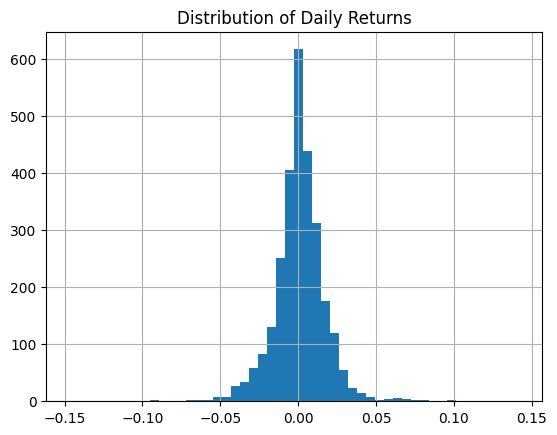

In [67]:
import matplotlib.pyplot as plt
data['Daily Returns'].hist(bins=50)
plt.title('Distribution of Daily Returns')
plt.show()


In [69]:
data['Daily Returns %']=data['Daily Returns']*100
data=data.drop(columns='Daily Returns')
data.head()

,Close,High,Low,Open,Volume,Daily Returns %
Date,,,,,,
2015-01-05,39.401989,39.742173,39.333950,39.436005,39673900,-0.919552
2015-01-06,38.823666,39.759174,38.730114,39.444504,36447900,-1.467752
2015-01-07,39.316944,39.512550,38.687603,39.104328,29114100,1.270561
2015-01-08,40.473560,40.609634,39.733658,39.759171,29645200,2.941775
2015-01-09,40.133404,40.669197,39.886772,40.490600,23944200,-0.840441


In [70]:
data['Daily Returns %'].describe()

count    2804.000000
mean        0.096250
std         1.706111
min       -14.739051
25%        -0.679654
50%         0.091880
75%         0.941814
max        14.216877
Name: Daily Returns %, dtype: float64

In [ ]:
data.loc[data['Daily Returns %'].idxmax()]
# Highest daily return percentage
# Friday, March 13, 2020 was the day that POTUS(President of the united states) declared a National Emergency for the COVID pandemic

Close              1.508737e+02
High               1.537994e+02
Low                1.336804e+02
Open               1.401112e+02
Volume             9.272740e+07
Daily Returns %    1.421688e+01
Name: 2020-03-13 00:00:00, dtype: float64

In [ ]:
data.loc[data['Daily Returns %'].idxmin()]
# lowest daily return %
# peak of COVID

Close              1.286363e+02
High               1.418685e+02
Low                1.282374e+02
Open               1.329869e+02
Volume             8.790590e+07
Daily Returns %   -1.473905e+01
Name: 2020-03-16 00:00:00, dtype: float64

In [77]:
data.nlargest(2,'Daily Returns %').iloc[-1]

Close              4.100144e+01
High               4.123270e+01
Low                3.909997e+01
Open               3.910854e+01
Volume             1.309337e+08
Daily Returns %    1.045228e+01
Name: 2015-04-24 00:00:00, dtype: float64

In [ ]:
data.nsmallest(2,'Daily Returns %').iloc[-1]
# fifth and final release of epstien files

Close              4.325128e+02
High               4.414923e+02
Low                4.200612e+02
Open               4.389880e+02
Volume             1.288553e+08
Daily Returns %   -9.993146e+00
Name: 2026-01-29 00:00:00, dtype: float64